In [1]:
!python -V

Python 3.10.20


In [2]:
!where python

/Users/cyberdemon/.pyenv/versions/3.10.20/bin/python
/opt/anaconda3/bin/python
/Users/cyberdemon/.pyenv/shims/python


In [3]:
%pip install tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Этап 1. Загрузка и предобработка данных

In [4]:
import torch
from torchvision.datasets import ImageFolder

dataset_path = './dataset/ogyeiv2'

train_dataset = ImageFolder(f'{dataset_path}/train')
test_dataset = ImageFolder(f'{dataset_path}/test')

acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg


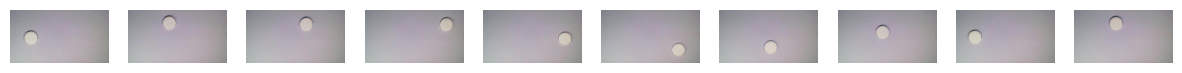

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(train_dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')


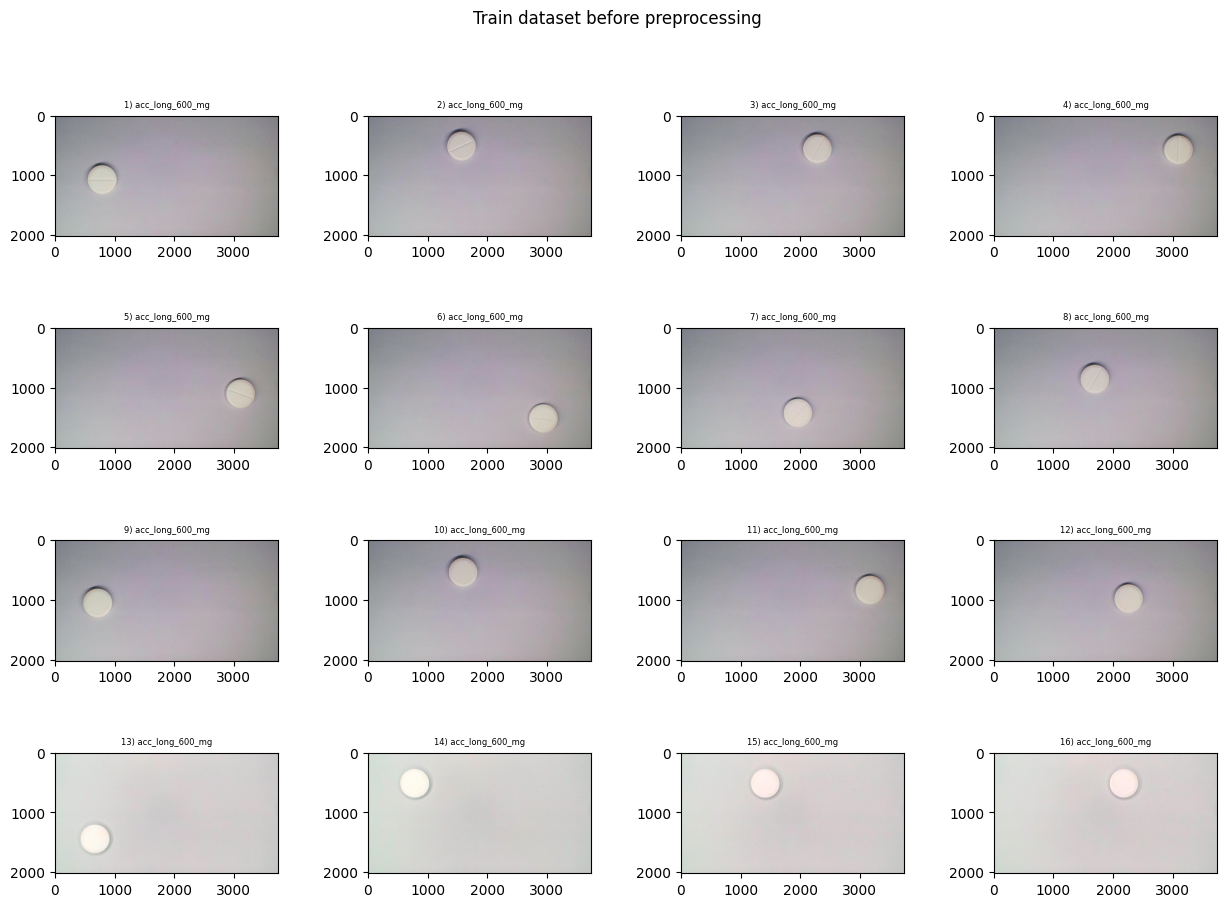

In [6]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = train_dataset[i]
    
    ax.axis('on')
    ax.imshow(image)
    ax.set_title(f'{i}) {train_dataset.classes[label]}', fontsize=6)

plt.suptitle('Train dataset before preprocessing')
plt.show()

acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte
advil_ultra_forte


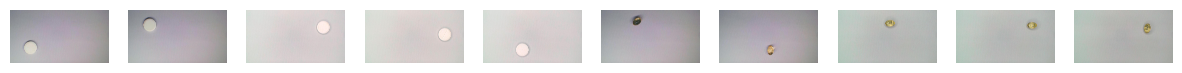

In [7]:
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = test_dataset[index]
    print(test_dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')

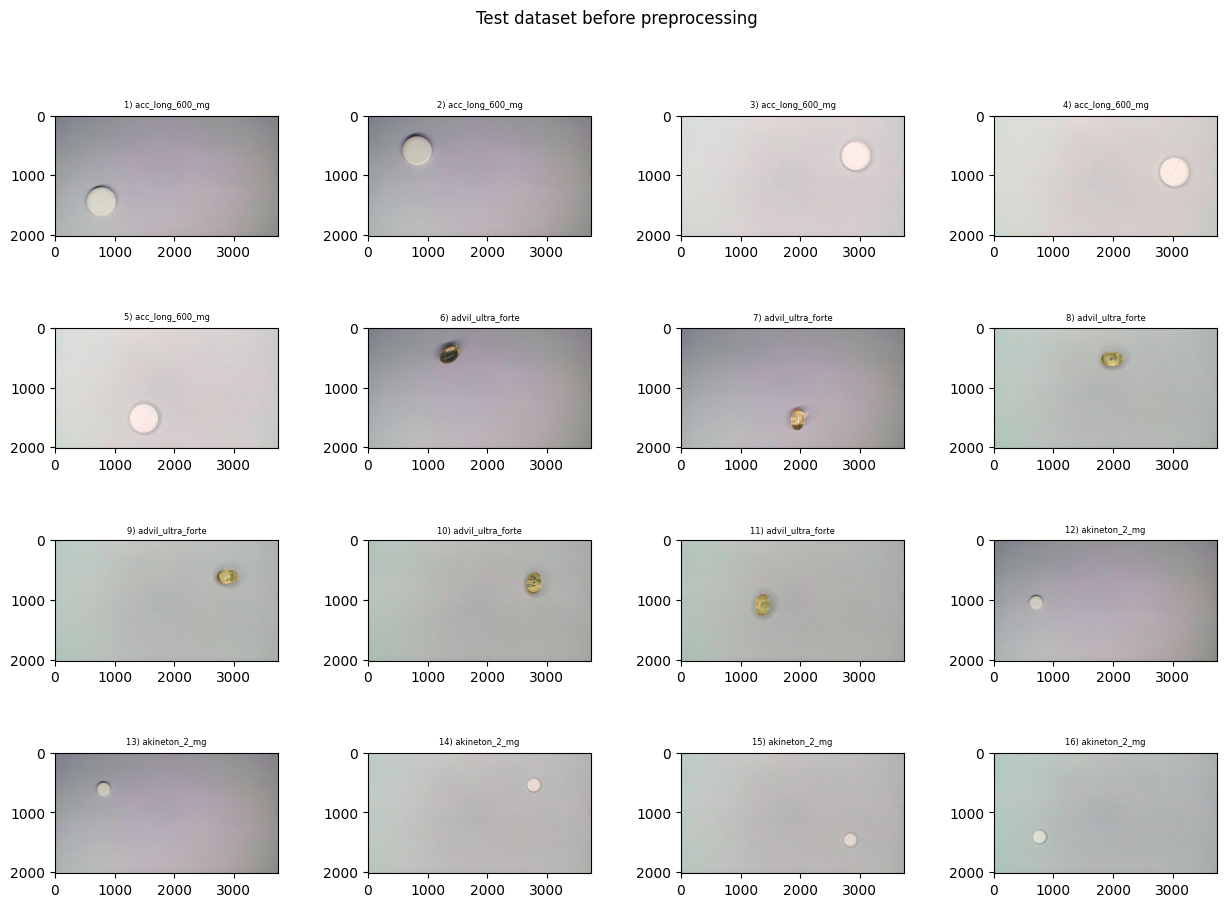

In [8]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = test_dataset[i]
    
    ax.axis('on')
    ax.imshow(image)
    ax.set_title(f'{i}) {test_dataset.classes[label]}', fontsize=6)

plt.suptitle('Test dataset before preprocessing')
plt.show()

In [9]:
from torchvision.transforms import Compose, Resize, Pad, ToTensor, Normalize
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation

train_transforms = Compose([
    # RandomHorizontalFlip(p=0.2),
    # RandomVerticalFlip(p=0.2),
    # RandomRotation([-5, 5], fill=255),
    # Pad((0, 500, 0, 500), fill=255),
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5)),
])

test_transforms = Compose([
    # Pad((0, 500, 0, 500), fill=255),
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5)),
])

In [10]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super().__init__()
    self.dataset = dataset
    self.transforms = transforms
    self.classes = dataset.classes

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y

In [11]:
train_dataset = TransformDataset(train_dataset, train_transforms)
val_dataset = TransformDataset(test_dataset, test_transforms)

In [12]:
print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset))

print("Количество классовв train:", len(train_dataset.classes))
print("Количество классов в val:", len(test_dataset.classes))

print("Список классовв train:", train_dataset.classes)
print("Список классов в val:", test_dataset.classes)

Количество изображений в train: 2352
Количество изображений в val: 504
Количество классовв train: 84
Количество классов в val: 84
Список классовв train: ['acc_long_600_mg', 'advil_ultra_forte', 'akineton_2_mg', 'algoflex_forte_dolo_400_mg', 'algoflex_rapid_400_mg', 'algopyrin_500_mg', 'ambroxol_egis_30_mg', 'apranax_550_mg', 'aspirin_ultra_500_mg', 'atoris_20_mg', 'atorvastatin_teva_20_mg', 'betaloc_50_mg', 'bila_git', 'c_vitamin_teva_500_mg', 'calci_kid', 'cataflam_50_mg', 'cataflam_dolo_25_mg', 'cetirizin_10_mg', 'cold_fx', 'coldrex', 'concor_10_mg', 'concor_5_mg', 'condrosulf_800_mg', 'controloc_20_mg', 'covercard_plus_10_mg_2_5_mg_5_mg', 'coverex_4_mg', 'diclopram_75-mg_20-mg', 'dorithricin_mentol', 'dulsevia_60_mg', 'enterol_250_mg', 'favipiravir_meditop_200_mg', 'ibumax_400_mg', 'jutavit_c_vitamin', 'jutavit_cink', 'kalcium_magnezium_cink', 'kalium_r', 'koleszterin_kontroll', 'lactamed', 'lactiv_plus', 'laresin_10_mg', 'letrox_50_mikrogramm', 'lordestin_5_mg', 'merckformin_xr_100

In [13]:
img, y = train_dataset[0]

print('Shape:', img.shape)
print('Class id:', y)
print('Class name:', train_dataset.classes[y])

Shape: torch.Size([3, 224, 224])
Class id: 0
Class name: acc_long_600_mg


In [14]:
img, y = val_dataset[0]

print('Shape:', img.shape)
print('Class id:', y)
print('Class name:', val_dataset.classes[y])

Shape: torch.Size([3, 224, 224])
Class id: 0
Class name: acc_long_600_mg


torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


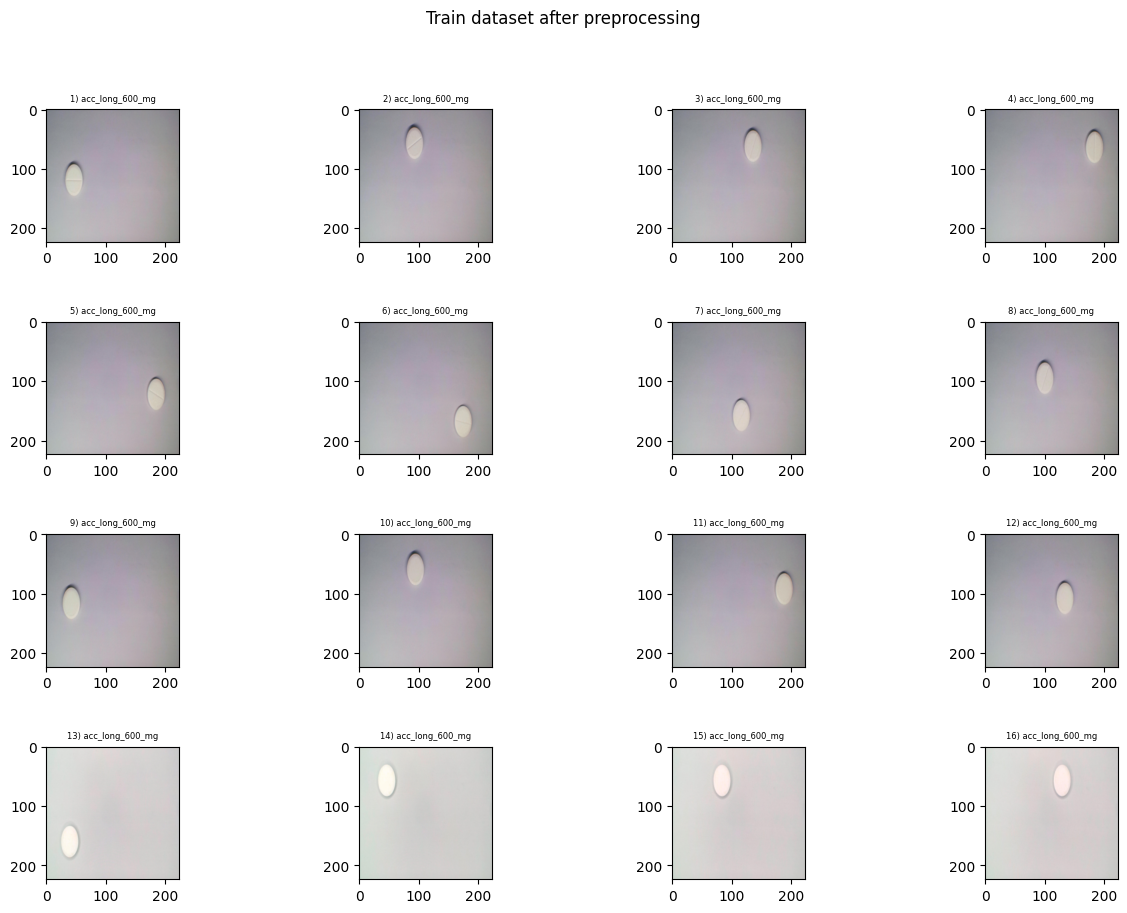

In [15]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = train_dataset[i]

    print(image.shape)
    
    ax.axis('on')
    img = image.cpu().permute(1,2,0) * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f'{i}) {train_dataset.classes[label]}', fontsize=6)

plt.suptitle('Train dataset after preprocessing')
plt.show()

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


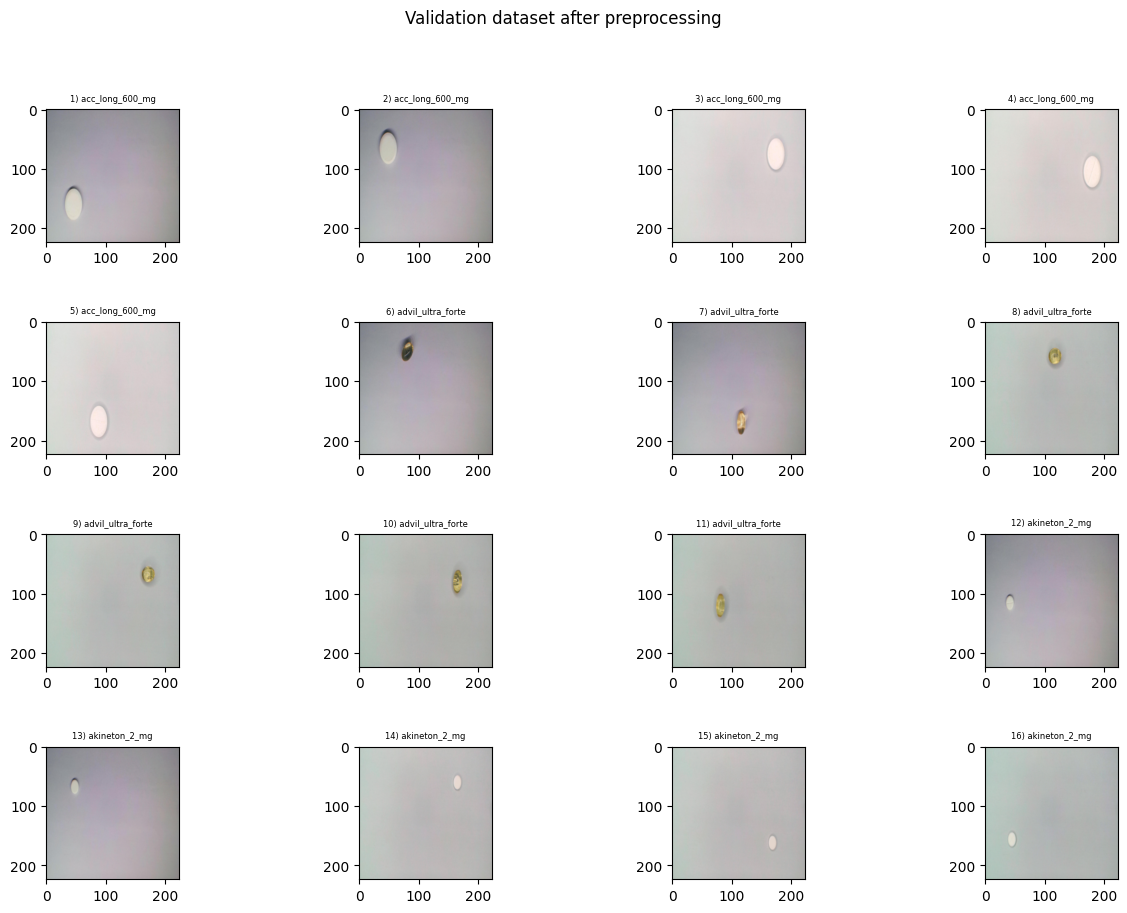

In [16]:
fig, axis = plt.subplots(4, 4, figsize=(15,10), gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

for i, ax in enumerate(axis.flat, start=1):
    image, label = val_dataset[i]

    print(image.shape)
    
    ax.axis('on')
    img = image.cpu().permute(1,2,0) * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f'{i}) {val_dataset.classes[label]}', fontsize=6)

plt.suptitle('Validation dataset after preprocessing')
plt.show()

In [17]:
import torch

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [18]:
print('Размер датасета train:', len(train_loader.dataset))
print('Размер датасета val:', len(val_loader.dataset))

print('Размер батча train:', len(train_loader))
print('Размер батча val:', len(val_loader))

Размер датасета train: 2352
Размер датасета val: 504
Размер батча train: 74
Размер батча val: 16


In [19]:
for batch_index, data in enumerate(train_loader, start=1):
    inputs, labels = data
    print(f'Train batch {batch_index}')

    for i in labels.tolist():
        print(i, train_dataset.classes[i])
    
    break

Train batch 1
38 lactiv_plus
7 apranax_550_mg
54 nolpaza_20_mg
17 cetirizin_10_mg
62 salazopyrin_en_500_mg
53 neo_ferro_folgamma_114_mg_0_8_mg
24 covercard_plus_10_mg_2_5_mg_5_mg
11 betaloc_50_mg
63 sedatif_pc
45 mezym_forte_10_000_egyseg
12 bila_git
75 urotrin
45 mezym_forte_10_000_egyseg
77 valeriana_teva
58 ocutein
15 cataflam_50_mg
59 olicard_60_mg
6 ambroxol_egis_30_mg
59 olicard_60_mg
65 sicor_10_mg
44 metothyrin_10_mg
27 dorithricin_mentol
58 ocutein
28 dulsevia_60_mg
45 mezym_forte_10_000_egyseg
64 semicillin_500_mg
26 diclopram_75-mg_20-mg
75 urotrin
45 mezym_forte_10_000_egyseg
67 strepfen_8_75_mg
73 tritace_5_mg
6 ambroxol_egis_30_mg


In [20]:
for batch_index, data in enumerate(val_loader, start=1):
    inputs, labels = data
    print(f'Validate batch {batch_index}')

    for i in labels.tolist():
        print(i, val_dataset.classes[i])
    
    break

Validate batch 1
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
0 acc_long_600_mg
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
1 advil_ultra_forte
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
2 akineton_2_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
3 algoflex_forte_dolo_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
4 algoflex_rapid_400_mg
5 algopyrin_500_mg
5 algopyrin_500_mg


In [21]:
print('Количество классов в тренировочном датасете:', len(train_dataset.classes))
print('Количество классов в валидационном датасете:', len(val_dataset.classes))

Количество классов в тренировочном датасете: 84
Количество классов в валидационном датасете: 84


In [22]:
%pip install torchsummary


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cpu'

In [24]:
# from torchvision.models import resnet50, ResNet50_Weights
# from torchsummary import summary

# # weights = ResNet50_Weights.DEFAULT
# # model = resnet50(weights=weights)
# model = resnet50(weights='IMAGENET1K_V2')

# # summary(model, input_size=(3, 224, 224), device=device)
# print(model)

In [25]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchsummary import summary

# weights = EfficientNet_B0_Weights.DEFAULT
# model = efficientnet_b0(weights=weights)
model = efficientnet_b0(weights='IMAGENET1K_V1')

# summary(model, input_size=(3, 224, 224), device=device)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# Обучение или дообучение

In [26]:
# from torch import nn

# for param in model.parameters():
#     param.requires_grad = False

# in_features = model.fc.in_features

# model.fc = nn.Sequential(
#     nn.Linear(in_features, 512),
#     nn.ReLU(),
#     nn.Dropout(0.3),
#     nn.Linear(512, len(train_dataset.classes))
# )

# for param in model.fc.parameters():
#     param.requires_grad = True

# print(model)

In [27]:
from torch import nn

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, len(train_dataset.classes))
)

for param in model.classifier.parameters():
    param.requires_grad = True

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    # model.fc.parameters(),
    model.classifier.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [29]:
def train_one_epoch(epoch_index):
    model.to(device)
    model.train()

    running_loss = 0.
    running_corrects = 0

    # for batch_index, data in enumerate(train_loader, start=1):
    for data in train_loader:
        # Извлечение батча
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        # print(f'{batch_index} train_loader', inputs.shape)
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model(inputs)
        # Подсчет ошибки
        loss = criterion(outputs, labels)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        # running_loss += loss.item()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)    
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    
    return epoch_loss, epoch_acc.item()

In [30]:
def val_one_epoch(epoch_index):
    model.to(device)
    model.eval()

    running_loss = 0.
    running_corrects = 0
    
    with torch.no_grad():
        # for batch_index, data in enumerate(val_loader, start=1):
        for data in val_loader:
                # Извлечение батча
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                # print(f'{batch_index} val_loader', inputs.shape)
                # Прямое распространение
                outputs = model(inputs)
                # Подсчет ошибки
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                # running_loss += loss.item()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(val_loader.dataset)    
    epoch_acc = running_corrects.double() / len(val_loader.dataset)

    return epoch_loss, epoch_acc.item()

In [31]:
import time

EPOCHS = 3

best_loss = 1e5

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]")

    start_time = time.time()

    # Перевод модели в режим обучения
    train_loss, train_acc = train_one_epoch(epoch)

    val_loss, val_acc = val_one_epoch(epoch)

    scheduler.step()

    elapsed = time.time() - start_time

    # Сохранение лучшей модели
    if val_loss < best_loss:
        best_loss = val_loss
        model_path = f'classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {train_loss}, ошибка val {val_loss}')
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")    
    print(f"Time: {elapsed:.1f} sec")
    print("-" * 50)

Epoch [1/3]
В конце эпохи ошибка train 3.9499193778654345, ошибка val 3.139060470792982
Train Loss: 3.9499 | Train Acc: 0.1709
Val Loss:   3.1391 | Val Acc:   0.4980
Time: 258.3 sec
--------------------------------------------------
Epoch [2/3]
В конце эпохи ошибка train 2.7497670488292667, ошибка val 2.2871465342385426
Train Loss: 2.7498 | Train Acc: 0.6148
Val Loss:   2.2871 | Val Acc:   0.6667
Time: 258.1 sec
--------------------------------------------------
Epoch [3/3]
В конце эпохи ошибка train 2.0726085147079156, ошибка val 1.7901997301313612
Train Loss: 2.0726 | Train Acc: 0.7474
Val Loss:   1.7902 | Val Acc:   0.7282
Time: 261.5 sec
--------------------------------------------------


# Оценка качества

In [32]:
# model_path = f'classifier_2.pt'

# model = resnet50()

# # for param in model.parameters():
# #     param.requires_grad = False

# in_features = model.fc.in_features

# model.fc = nn.Sequential(
#     nn.Linear(in_features, 512),
#     nn.ReLU(),
#     nn.Dropout(0.3),
#     nn.Linear(512, len(train_dataset.classes))
# )

# # for param in model.fc.parameters():
# #     param.requires_grad = True

# model.to(device)

# model.load_state_dict(torch.load(model_path, weights_only=True))

In [33]:
model_path = f'classifier_2.pt'

model2 = efficientnet_b0()

# for param in model2.parameters():
#     param.requires_grad = False

in_features = model2.classifier[1].in_features

model2.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, len(train_dataset.classes))
)

# for param in model2.classifier.parameters():
#     param.requires_grad = True

model2.to(device)

model2.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

### Рассчитайте метрики обученного классификатора, используя проверочный датасет. 
### Выведите метрики для каждого класса (Precision, Recall, F1) и accuracy для каждого класса. 

In [ ]:
# from sklearn.metrics import classification_report

# labels_predicted = []
# labels_true = []

# model.eval()

# with torch.no_grad():
#     for batch_index, data in enumerate(val_loader, start=1):
#         # Извлечение батча
#         inputs, labels = data
#         inputs, labels = inputs.to(device), labels.to(device)
#         # print(f'{batch_index} val_loader', inputs.shape)
#         # Прямое распространение
#         outputs = model(inputs)
#         _, predicted = torch.max(outputs, dim=1) # argmax по всем примерам
#         labels_predicted.extend(predicted.numpy())
#         labels_true.extend(labels.numpy())

# print(classification_report(labels_true, labels_predicted, target_names=val_dataset.classes, zero_division=0))

                                  precision    recall  f1-score   support

                 acc_long_600_mg       1.00      1.00      1.00         6
               advil_ultra_forte       1.00      1.00      1.00         6
                   akineton_2_mg       0.83      0.83      0.83         6
      algoflex_forte_dolo_400_mg       0.80      0.67      0.73         6
           algoflex_rapid_400_mg       1.00      0.83      0.91         6
                algopyrin_500_mg       0.67      1.00      0.80         6
             ambroxol_egis_30_mg       1.00      0.83      0.91         6
                  apranax_550_mg       0.86      1.00      0.92         6
            aspirin_ultra_500_mg       0.50      0.67      0.57         6
                    atoris_20_mg       1.00      0.83      0.91         6
         atorvastatin_teva_20_mg       1.00      0.33      0.50         6
                   betaloc_50_mg       0.86      1.00      0.92         6
                        bila_git     

In [35]:
from sklearn.metrics import classification_report

labels_predicted = []
labels_true = []

model2.eval()

with torch.no_grad():
    for batch_index, data in enumerate(val_loader, start=1):
        # Извлечение батча
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        # print(f'{batch_index} val_loader', inputs.shape)
        # Прямое распространение
        outputs = model2(inputs)
        _, predicted = torch.max(outputs, dim=1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())

print(classification_report(labels_true, labels_predicted, target_names=val_dataset.classes, zero_division=0))

                                  precision    recall  f1-score   support

                 acc_long_600_mg       1.00      1.00      1.00         6
               advil_ultra_forte       1.00      1.00      1.00         6
                   akineton_2_mg       0.83      0.83      0.83         6
      algoflex_forte_dolo_400_mg       0.80      0.67      0.73         6
           algoflex_rapid_400_mg       1.00      0.83      0.91         6
                algopyrin_500_mg       0.67      1.00      0.80         6
             ambroxol_egis_30_mg       1.00      0.83      0.91         6
                  apranax_550_mg       0.86      1.00      0.92         6
            aspirin_ultra_500_mg       0.50      0.67      0.57         6
                    atoris_20_mg       1.00      0.83      0.91         6
         atorvastatin_teva_20_mg       1.00      0.33      0.50         6
                   betaloc_50_mg       0.86      1.00      0.92         6
                        bila_git     

### Precision (Точность) — показывает, какая доля изображений, которые модель отнесла к этому классу, действительно принадлежит ему. Эта метрика важна, когда цена ложного срабатывания (False Positive) высока.
### Recall (Полнота) — показывает, какую долю изображений этого класса из всех реально существующих модель смогла найти. Полнота критична, когда цена пропуска (False Negative) очень велика (например, при поиске дефектов одежды пропустить брак хуже, чем ошибочно отправить на повторную проверку хорошую вещь).
### F1-score (F-мера) — гармоническое среднее между точностью и полнотой. Если одна из метрик (Precision или Recall) проседает, F1-score тоже будет низким. Это отличная комплексная оценка баланса работы сети.
### Support (Поддержка) — количество объектов каждого класса в валидационной выборке. Помогает понять баланс классов.

## Оцените полученные метрики, ответив на вопросы:
### На каких 5 классах модель ошибается чаще всего?
### Почему модель может ошибаться на этих классах?
### На каких классах модель не совершает ошибок?
### Почему эти классы модель распознаёт безошибочно?
### Как можно улучшить точность классификатора?
### Как ещё можно проанализировать результаты и ошибки модели?


<!-- import timm

model = timm.create_model('efficientnet_b0', pretrained=True)

print(model.classifier.weight) -->